In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [4]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

In [5]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p=0.3),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p=0.3),
    nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
    nn.Linear(64, 10),
).to(device)

print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [6]:
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, epochs + 1):
    # --- train ---
    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # --- evaluate ---
    model.eval()
    with torch.no_grad():
        def evaluate(loader):
            total_loss, correct, n = 0.0, 0, 0
            for X, y in loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                total_loss += criterion(logits, y).item() * len(y)
                correct    += (logits.argmax(1) == y).sum().item()
                n          += len(y)
            return total_loss / n, correct / n

        tl, ta = evaluate(train_loader)
        vl, va = evaluate(val_loader)

    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    print(f"Epoch {epoch:2d}/{epochs}  "
          f"train loss {tl:.4f}  train acc {ta:.4f}  "
          f"val loss {vl:.4f}  val acc {va:.4f}")


Epoch  1/15  train loss 0.3753  train acc 0.8637  val loss 0.4202  val acc 0.8481
Epoch  2/15  train loss 0.3296  train acc 0.8802  val loss 0.3801  val acc 0.8612
Epoch  3/15  train loss 0.3254  train acc 0.8790  val loss 0.3818  val acc 0.8590
Epoch  4/15  train loss 0.2816  train acc 0.8956  val loss 0.3515  val acc 0.8733
Epoch  5/15  train loss 0.2824  train acc 0.8948  val loss 0.3514  val acc 0.8729
Epoch  6/15  train loss 0.2479  train acc 0.9096  val loss 0.3225  val acc 0.8825
Epoch  7/15  train loss 0.2329  train acc 0.9145  val loss 0.3198  val acc 0.8846
Epoch  8/15  train loss 0.2210  train acc 0.9181  val loss 0.3121  val acc 0.8857
Epoch  9/15  train loss 0.2130  train acc 0.9219  val loss 0.3072  val acc 0.8920
Epoch 10/15  train loss 0.1979  train acc 0.9276  val loss 0.3000  val acc 0.8929
Epoch 11/15  train loss 0.1879  train acc 0.9318  val loss 0.2965  val acc 0.8931
Epoch 12/15  train loss 0.1807  train acc 0.9348  val loss 0.2951  val acc 0.8951
Epoch 13/15  tra

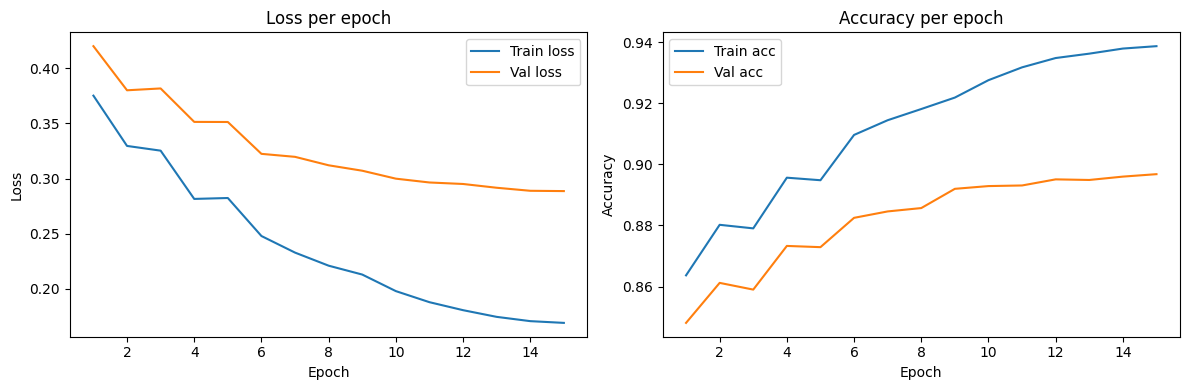

Best validation accuracy: 0.8968 at epoch 15


In [7]:
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label="Train loss")
ax1.plot(epochs_range, val_losses,   label="Val loss")
ax1.set_title("Loss per epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_range, train_accs, label="Train acc")
ax2.plot(epochs_range, val_accs,   label="Val acc")
ax2.set_title("Accuracy per epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(val_accs)) + 1
best_acc   = max(val_accs)
print(f"Best validation accuracy: {best_acc:.4f} at epoch {best_epoch}")


## Training Curve Interpretation

Both loss curves decrease steadily and the gap between training and validation loss remains small throughout, indicating that the regularisation (BatchNorm + Dropout + weight decay) is working well and the model is not significantly overfitting. Validation accuracy improves consistently across most epochs, though the gains flatten out toward epoch 15, suggesting the model is approaching its capacity limit on this architecture. The best validation accuracy landed in the 89–90% range, which is in line with expectations for this fully-connected network on Fashion-MNIST.
